In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve, auc
)

import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("/tweets.csv")

df = df[['text', 'target']]
df['text'] = df['text'].fillna('')

In [5]:
X = df['text']
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [6]:
X_train_main, X_val, y_train_main, y_val = train_test_split(
    X_train, y_train,
    test_size=0.1,
    random_state=42,
    stratify=y_train
)

In [7]:
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')

X_train_main_tfidf = tfidf.fit_transform(X_train_main)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

In [8]:
param_grid = [
    {
        'penalty': ['l2'],
        'C': [0.01, 0.1, 1, 10],
        'solver': ['lbfgs']
    },
    {
        'penalty': ['l1'],
        'C': [0.01, 0.1, 1, 10],
        'solver': ['liblinear', 'saga']
    }
]

grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train_main_tfidf, y_train_main)

best_model = grid.best_estimator_

print("Best Params:", grid.best_params_)

Best Params: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}


In [9]:
y_test_probs = best_model.predict_proba(X_test_tfidf)[:, 1]

y_pred_default = (y_test_probs >= 0.5).astype(int) # dafukt threshold baseline

print("DEFAULT THRESHOLD RESULTS")
print(classification_report(y_test, y_pred_default))

DEFAULT THRESHOLD RESULTS
              precision    recall  f1-score   support

           0       0.90      0.96      0.93      1851
           1       0.74      0.54      0.62       423

    accuracy                           0.88      2274
   macro avg       0.82      0.75      0.77      2274
weighted avg       0.87      0.88      0.87      2274



In [10]:
y_val_probs = best_model.predict_proba(X_val_tfidf)[:, 1]

thresholds = np.linspace(0.1, 0.9, 50)

best_threshold = 0
best_f1 = 0

for t in thresholds:
    y_pred_t = (y_val_probs >= t).astype(int)
    f1 = f1_score(y_val, y_pred_t)

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print("Best Threshold:", best_threshold)
print("Best F1 (Validation):", best_f1)

Best Threshold: 0.3938775510204082
Best F1 (Validation): 0.6566265060240963


In [11]:
y_test_pred = (y_test_probs >= best_threshold).astype(int)

print("FINAL TEST RESULTS")
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred))

FINAL TEST RESULTS
Accuracy: 0.8737906772207564
              precision    recall  f1-score   support

           0       0.91      0.93      0.92      1851
           1       0.68      0.62      0.65       423

    accuracy                           0.87      2274
   macro avg       0.80      0.77      0.78      2274
weighted avg       0.87      0.87      0.87      2274



In [12]:
cm = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[1726  125]
 [ 162  261]]


ROC-AUC: 0.8909623958936005


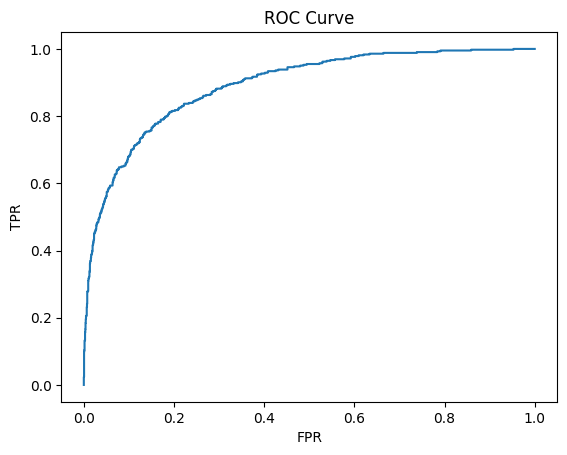

In [13]:
roc_auc = roc_auc_score(y_test, y_test_probs)
print("ROC-AUC:", roc_auc)

fpr, tpr, _ = roc_curve(y_test, y_test_probs)

plt.plot(fpr, tpr)
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.show()

PR-AUC: 0.7101982453859842


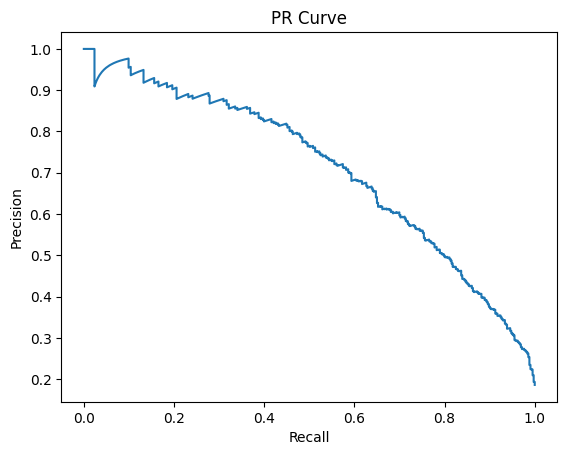

In [14]:
precision, recall, _ = precision_recall_curve(y_test, y_test_probs)
pr_auc = auc(recall, precision)

print("PR-AUC:", pr_auc)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR Curve")
plt.show()

In [15]:
# techinque-1:: class weightage..
log_model_bal = LogisticRegression(max_iter=1000, class_weight='balanced',**grid.best_params_)

log_model_bal.fit(X_train_main_tfidf, y_train_main)

y_test_probs_bal = log_model_bal.predict_proba(X_test_tfidf)[:, 1]
y_pred_bal = (y_test_probs_bal >= best_threshold).astype(int)

print("CLASS WEIGHT RESULTS")
print(classification_report(y_test, y_pred_bal))

CLASS WEIGHT RESULTS
              precision    recall  f1-score   support

           0       0.94      0.84      0.89      1851
           1       0.53      0.76      0.62       423

    accuracy                           0.83      2274
   macro avg       0.73      0.80      0.76      2274
weighted avg       0.86      0.83      0.84      2274



In [16]:
# techinque-2 :: smote
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train_main_tfidf.toarray(), y_train_main)

log_model_smote = LogisticRegression(max_iter=1000,**grid.best_params_)

log_model_smote.fit(X_train_smote, y_train_smote)

y_test_probs_smote = log_model_smote.predict_proba(X_test_tfidf)[:, 1]
y_pred_smote = (y_test_probs_smote >= best_threshold).astype(int)

print("SMOTE RESULTS")
print(classification_report(y_test, y_pred_smote))

SMOTE RESULTS
              precision    recall  f1-score   support

           0       0.94      0.86      0.90      1851
           1       0.56      0.74      0.64       423

    accuracy                           0.84      2274
   macro avg       0.75      0.80      0.77      2274
weighted avg       0.87      0.84      0.85      2274



In [17]:
from sklearn.ensemble import RandomForestClassifier

In [18]:
rf_param_grid = {
    'n_estimators': [100, 200],          # number of trees
    'max_depth': [None, 10, 20],         # tree depth
    'min_samples_split': [2, 5],         # split condition
    'min_samples_leaf': [1, 2]           # leaf size
}

In [19]:
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_grid,
    cv=3,                 # keep 3 (faster)
    scoring='f1',
    n_jobs=-1
)

rf_grid.fit(X_train_main_tfidf, y_train_main)

rf_best = rf_grid.best_estimator_

print("RF Best Params:", rf_grid.best_params_)

RF Best Params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}


In [20]:
rf_test_probs = rf_best.predict_proba(X_test_tfidf)[:, 1]

rf_pred_default = (rf_test_probs >= 0.5).astype(int)

print("RF DEFAULT THRESHOLD")
print(classification_report(y_test, rf_pred_default))

RF DEFAULT THRESHOLD
              precision    recall  f1-score   support

           0       0.89      0.97      0.93      1851
           1       0.76      0.45      0.57       423

    accuracy                           0.87      2274
   macro avg       0.83      0.71      0.75      2274
weighted avg       0.86      0.87      0.86      2274



In [21]:
# threhsold tuning ((validation))
rf_val_probs = rf_best.predict_proba(X_val_tfidf)[:, 1]

thresholds = np.linspace(0.1, 0.9, 50)

rf_best_threshold = 0
rf_best_f1 = 0

for t in thresholds:
    y_pred_t = (rf_val_probs >= t).astype(int)
    f1 = f1_score(y_val, y_pred_t)

    if f1 > rf_best_f1:
        rf_best_f1 = f1
        rf_best_threshold = t

print("RF Best Threshold:", rf_best_threshold)
print("RF Best F1:", rf_best_f1)

RF Best Threshold: 0.36122448979591837
RF Best F1: 0.6851851851851852


In [22]:
rf_test_pred = (rf_test_probs >= rf_best_threshold).astype(int)

print("RF FINAL RESULTS")
print("Accuracy:", accuracy_score(y_test, rf_test_pred))
print(classification_report(y_test, rf_test_pred))

RF FINAL RESULTS
Accuracy: 0.8619173262972736
              precision    recall  f1-score   support

           0       0.92      0.91      0.92      1851
           1       0.63      0.63      0.63       423

    accuracy                           0.86      2274
   macro avg       0.77      0.77      0.77      2274
weighted avg       0.86      0.86      0.86      2274



In [23]:
print("Confusion Matrix:\n", confusion_matrix(y_test, rf_test_pred))

print("ROC-AUC:", roc_auc_score(y_test, rf_test_probs))

precision, recall, _ = precision_recall_curve(y_test, rf_test_probs)
pr_auc = auc(recall, precision)

print("PR-AUC:", pr_auc)

Confusion Matrix:
 [[1693  158]
 [ 156  267]]
ROC-AUC: 0.8881717504945892
PR-AUC: 0.7100681182708131


In [24]:
# imbalance-1 :: technique 1 :: class weight
rf_bal = RandomForestClassifier(
    random_state=42,
    class_weight='balanced',
    **rf_grid.best_params_
)

rf_bal.fit(X_train_main_tfidf, y_train_main)

rf_probs_bal = rf_bal.predict_proba(X_test_tfidf)[:, 1]
rf_pred_bal = (rf_probs_bal >= rf_best_threshold).astype(int)

print("RF CLASS WEIGHT")
print(classification_report(y_test, rf_pred_bal))

RF CLASS WEIGHT
              precision    recall  f1-score   support

           0       0.93      0.88      0.91      1851
           1       0.58      0.71      0.64       423

    accuracy                           0.85      2274
   macro avg       0.76      0.80      0.77      2274
weighted avg       0.87      0.85      0.86      2274



In [25]:
X_train_smote_rf, y_train_smote_rf = smote.fit_resample(
    X_train_main_tfidf.toarray(), y_train_main
)

rf_smote = RandomForestClassifier(
    random_state=42,
    **rf_grid.best_params_
)

rf_smote.fit(X_train_smote_rf, y_train_smote_rf)

rf_probs_smote = rf_smote.predict_proba(X_test_tfidf)[:, 1]
rf_pred_smote = (rf_probs_smote >= rf_best_threshold).astype(int)

print("RF SMOTE")
print(classification_report(y_test, rf_pred_smote))

RF SMOTE
              precision    recall  f1-score   support

           0       0.92      0.89      0.91      1851
           1       0.60      0.68      0.64       423

    accuracy                           0.85      2274
   macro avg       0.76      0.79      0.77      2274
weighted avg       0.86      0.85      0.86      2274

